# 08 — Poster Visualizations

Generates all publication-quality figures used in the FURI research poster.
All figures saved at 300 DPI with white backgrounds.

**Inputs:** `data/processed/nyc_sample_with_sentiment.csv`,
`google_reviews_nyc.csv`, `google_reviews_ch.csv`, `google_reviews_mc.csv`  
**Outputs:** `fig2_city_comparison.png`, `fig3_tweet_stats.png`, `fig4_pipeline.png`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load your data
tweets = pd.read_csv("../data/processed/nyc_sample_with_sentiment.csv")
nyc = pd.read_csv("../data/processed/google_reviews_nyc.csv")  # adjust paths as needed
ch  = pd.read_csv("../data/processed/google_reviews_ch.csv")
mc  = pd.read_csv("../data/processed/google_reviews_mc.csv")

# ASU colors
MAROON = '#8C1D40'
GOLD   = '#FFC627'
GREEN  = '#388E3C'
GRAY   = '#888888'

## Figure 1: Greenspace Review Sentiment by City

Two-panel figure showing:
- **Left:** Stacked bar chart of positive vs. negative review percentages
  across NYC, Chicago, and Maricopa County
- **Right:** Average star rating per city with a 4.5 baseline reference line

All three cities show strong positive sentiment (88-97%) and ratings above
4.5/5, suggesting residents respond favorably to greenspace when actively
visiting it.

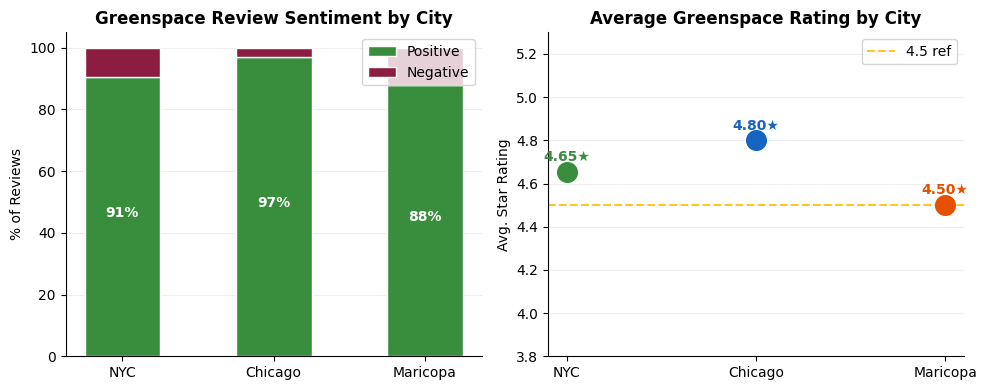

In [7]:
cities = ['NYC', 'Chicago', 'Maricopa']
dfs    = [nyc, ch, mc]

pos_pcts, neg_pcts, ratings = [], [], []
for d in dfs:
    s = d['sentiment'].str.upper()
    total = len(d)
    pos_pcts.append(s.eq('POSITIVE').sum() / total * 100)
    neg_pcts.append(s.eq('NEGATIVE').sum() / total * 100)
    ratings.append(d['rating'].mean())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left: stacked bar
ax = axes[0]
x = np.arange(3)
b1 = ax.bar(x, pos_pcts, 0.5, label='Positive', color=GREEN, edgecolor='white')
b2 = ax.bar(x, neg_pcts, 0.5, bottom=pos_pcts, label='Negative', color=MAROON, edgecolor='white')

for bar, pct in zip(b1, pos_pcts):
    ax.text(bar.get_x() + bar.get_width()/2, pct/2,
            f'{pct:.0f}%', ha='center', fontsize=10, fontweight='bold', color='white')

ax.set_xticks(x)
ax.set_xticklabels(cities)
ax.set_ylabel('% of Reviews')
ax.set_title('Greenspace Review Sentiment by City', fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, color='#EEEEEE')
ax.set_axisbelow(True)

# Right: avg rating dot plot
ax2 = axes[1]
colors = [GREEN, '#1565C0', '#E65100']
for i, (r, c) in enumerate(zip(ratings, colors)):
    ax2.scatter(i, r, s=200, color=c, zorder=3)
    ax2.text(i, r + 0.05, f'{r:.2f}★', ha='center', fontsize=10,
             fontweight='bold', color=c)

ax2.set_xticks(range(3))
ax2.set_xticklabels(cities)
ax2.set_ylim(3.8, 5.3)
ax2.set_ylabel('Avg. Star Rating')
ax2.set_title('Average Greenspace Rating by City', fontweight='bold')
ax2.axhline(4.5, color=GOLD, linewidth=1.5, linestyle='--', label='4.5 ref')
ax2.legend()
ax2.spines[['top', 'right']].set_visible(False)
ax2.yaxis.grid(True, color='#EEEEEE')
ax2.set_axisbelow(True)

plt.tight_layout()
plt.savefig('fig2_city_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure 2: NYC Tweet Sentiment Distribution

Two-panel figure showing:
- **Left:** Pie chart of tweet sentiment distribution (n=20,000)
- **Right:** Key metric callouts — positive %, negative %, and avg.
  model confidence score

Classified using Cardiff NLP's Twitter-RoBERTa-base model. The slight
positive bias (mean = +0.064) is consistent across the dataset regardless
of NDVI values at user locations.

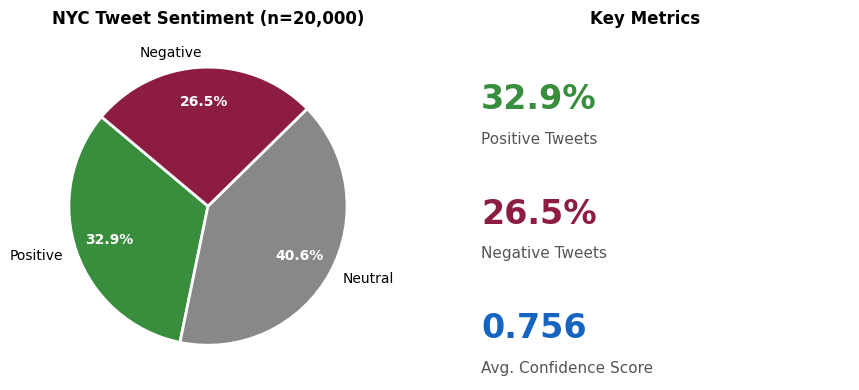

In [8]:
counts = tweets['sentiment_label'].value_counts().reindex(['positive', 'neutral', 'negative'])
pcts   = counts / counts.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

# Pie
ax = axes[0]
wedges, texts, autotexts = ax.pie(
    counts.values,
    labels=['Positive', 'Neutral', 'Negative'],
    colors=[GREEN, GRAY, MAROON],
    autopct='%1.1f%%', startangle=140,
    pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=2))
for t in autotexts:
    t.set_color('white')
    t.set_fontweight('bold')
ax.set_title('NYC Tweet Sentiment (n=20,000)', fontweight='bold')

# Stat callouts
ax2 = axes[1]
ax2.axis('off')
stats = [
    (f"{pcts['positive']:.1f}%", 'Positive Tweets', GREEN),
    (f"{pcts['negative']:.1f}%", 'Negative Tweets', MAROON),
    (f"{tweets['sentiment_score'].mean():.3f}", 'Avg. Confidence Score', '#1565C0'),
]
for i, (val, label, c) in enumerate(stats):
    y = 0.78 - i * 0.33
    ax2.text(0.1, y, val, transform=ax2.transAxes,
             fontsize=24, fontweight='bold', color=c)
    ax2.text(0.1, y - 0.1, label, transform=ax2.transAxes,
             fontsize=11, color='#555555')
ax2.set_title('Key Metrics', fontweight='bold')

plt.tight_layout()
plt.savefig('fig3_tweet_stats.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure 3: Analysis Pipeline Diagram

Visual summary of the end-to-end methodology: Sentinel-2 satellite imagery
and geo-tagged text data are processed independently then joined spatially
for correlation analysis.

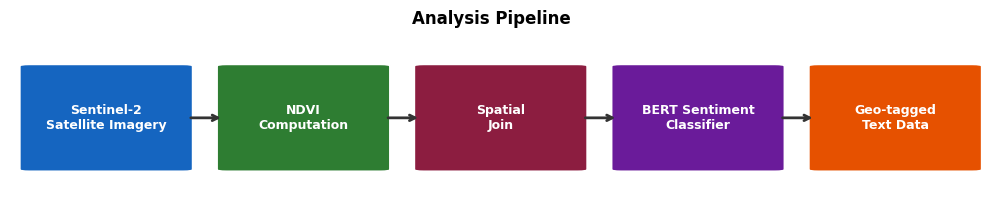

In [4]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 2.2))
ax.axis('off')

steps = [
    ('Sentinel-2\nSatellite Imagery', '#1565C0'),
    ('NDVI\nComputation',             '#2E7D32'),
    ('Spatial\nJoin',                  MAROON),
    ('BERT Sentiment\nClassifier',     '#6A1B9A'),
    ('Geo-tagged\nText Data',          '#E65100'),
]

box_w, box_h, gap = 0.16, 0.62, 0.045
starts = [0.02 + i * (box_w + gap) for i in range(5)]

for i, (label, color) in enumerate(steps):
    x = starts[i]
    rect = mpatches.FancyBboxPatch(
        (x, 0.18), box_w, box_h,
        boxstyle="round,pad=0.01",
        facecolor=color, edgecolor='white', linewidth=1.5,
        transform=ax.transAxes, clip_on=False)
    ax.add_patch(rect)
    ax.text(x + box_w/2, 0.18 + box_h/2, label,
            transform=ax.transAxes, ha='center', va='center',
            fontsize=9, fontweight='bold', color='white',
            multialignment='center')
    if i < 4:
        arrow_x = x + box_w + 0.005
        ax.annotate('', xy=(arrow_x + gap - 0.008, 0.49),
                    xytext=(arrow_x, 0.49),
                    xycoords='axes fraction', textcoords='axes fraction',
                    arrowprops=dict(arrowstyle='->', color='#333333', lw=2))

ax.set_title('Analysis Pipeline', fontsize=12, fontweight='bold', pad=6)
plt.tight_layout()
plt.savefig('fig4_pipeline.png', dpi=200, bbox_inches='tight')
plt.show()